In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
df = pd.read_csv('heart.csv')
print(f'Shape: {df.shape}')
print(f'columns:\n{df.columns}')
df.head()

Shape: (918, 12)
columns:
Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [4]:
data = df.copy()
encoder = LabelEncoder()
for col in data.select_dtypes(include=['object','str']).columns:
    data[col] = encoder.fit_transform(data[col])

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


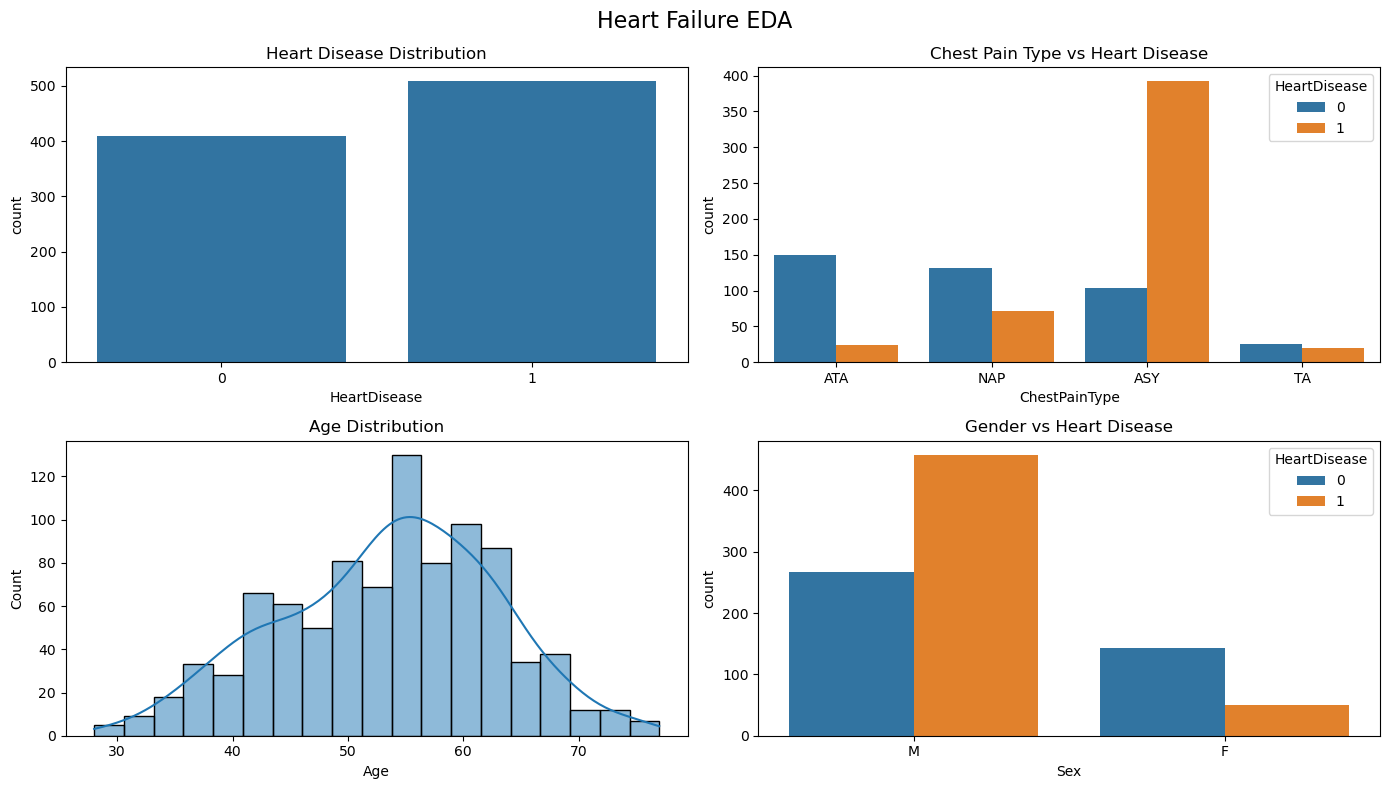

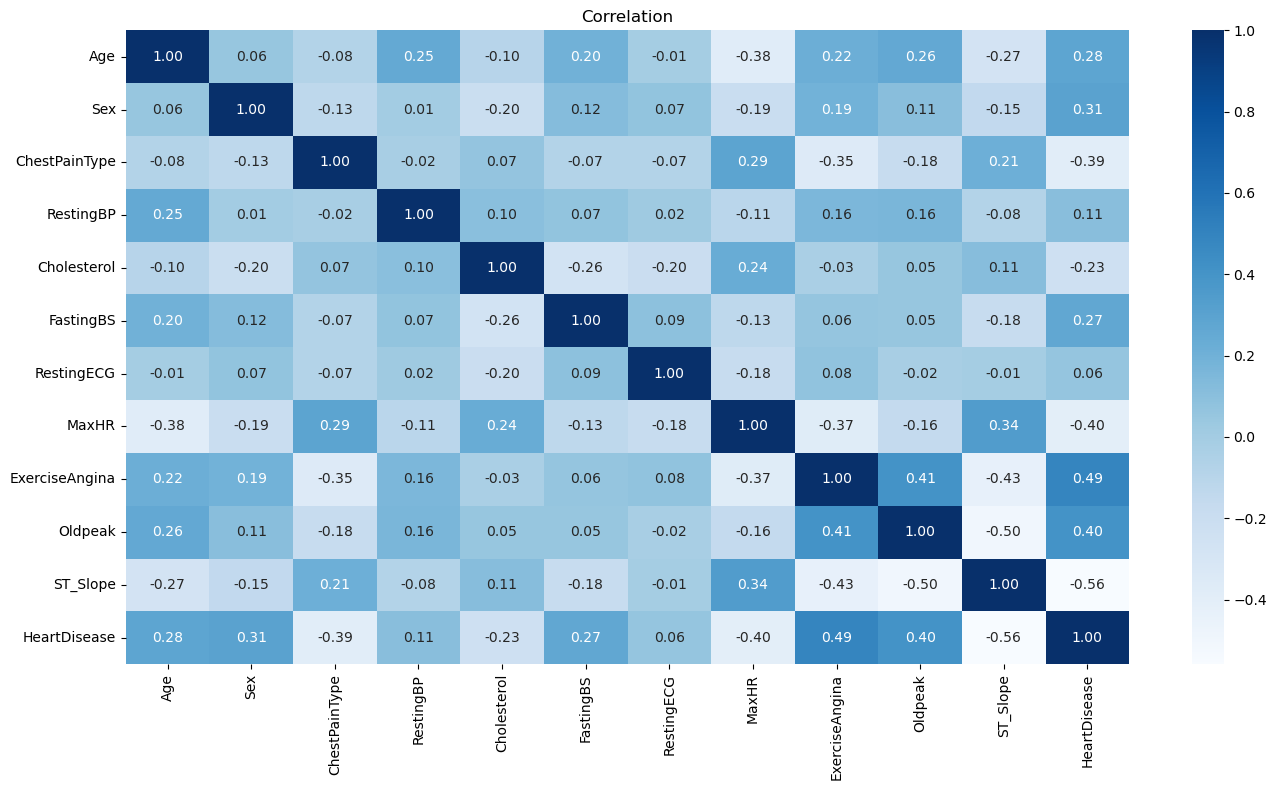

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,0.781046,132.396514,198.799564,0.233115,0.989107,136.809368,0.404139,0.887364,1.361656,0.553377
std,9.432617,0.407701,0.956519,18.514154,109.384145,0.423046,0.631671,25.460334,0.490992,1.066570,0.607056,0.497414
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,173.250000,0.000000,1.000000,120.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,1.000000,138.000000,0.000000,0.600000,1.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,1.000000


In [5]:
fig, axes = plt.subplots(2,2, figsize=(14,8))
fig.suptitle('Heart Failure EDA', fontsize=16)

sns.countplot(data=df, x=df['HeartDisease'], ax=axes[0,0])
axes[0,0].set_title('Heart Disease Distribution')

sns.countplot(data=df, x=df['ChestPainType'], hue='HeartDisease', ax=axes[0,1])
axes[0,1].set_title('Chest Pain Type vs Heart Disease')

sns.histplot(df['Age'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Age Distribution')

sns.countplot(data=df, x=df['Sex'], hue='HeartDisease', ax=axes[1,1])
axes[1,1].set_title('Gender vs Heart Disease')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,8))
sns.heatmap(data.corr(), fmt='.2f', annot=True, cmap='Blues')
plt.title('Correlation')
plt.tight_layout()
plt.show()

data.describe()

In [6]:
x = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

x = torch.tensor(x.to_numpy(), dtype=torch.float32)
y = torch.tensor(y.to_numpy(), dtype=torch.float32)

dataset = TensorDataset(x, y)

train_dataset, val_dataset = random_split(dataset, [700, 218])
print(f'Train Shape: {len(train_dataset)}')
print(f'Validation Shape: {len(val_dataset)}')

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

Train Shape: 700
Validation Shape: 218


In [7]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(11, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)
        self.layer2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.act2 = nn.ReLU()
        self.layer3 = nn.Linear(16,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.drop1(self.act1(self.bn1(self.layer1(x))))
        x = self.act2(self.bn2(self.layer2(x)))
        x = self.sigmoid(self.layer3(x))
        return x
model = Net().to(device)

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
epochs = 500
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for xbatch, ybatch in train_loader:
        xbatch = xbatch.to(device)
        ybatch = ybatch.to(device)
        y_pred = model(xbatch).squeeze()
        loss = loss_fn(y_pred, ybatch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_val_batch, y_val_batch in val_loader:
            x_val_batch = x_val_batch.to(device)
            y_val_batch = y_val_batch.to(device)
            y_val_pred = model(x_val_batch).squeeze()
            loss = loss_fn(y_val_pred, y_val_batch)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)    
    
    if epoch % 100 == 0:
        print(
            f'Epoch: {epoch} | '
            f'Train Loss: {train_loss:.4f} | '
            f'Val Loss: {val_loss:.4f}'
        )

Epoch: 0 | Train Loss: 0.7004 | Val Loss: 0.6317
Epoch: 100 | Train Loss: 0.3599 | Val Loss: 0.2958
Epoch: 200 | Train Loss: 0.3326 | Val Loss: 0.2724
Epoch: 300 | Train Loss: 0.3104 | Val Loss: 0.2732
Epoch: 400 | Train Loss: 0.3286 | Val Loss: 0.2626


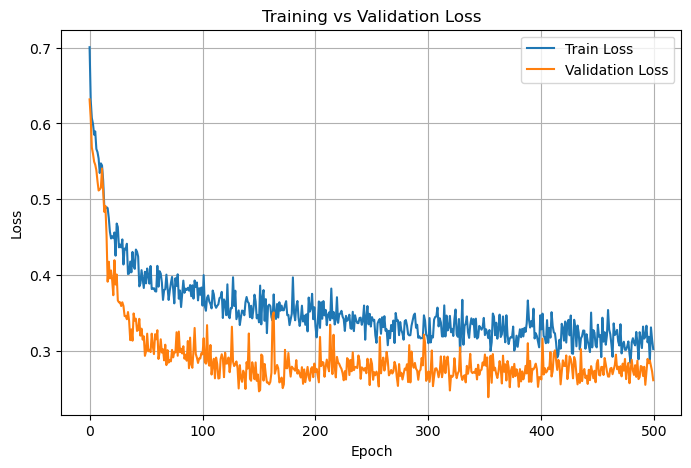

In [9]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()

plt.show()

Accuracy: 0.8899
Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.84      0.86        89
         1.0       0.89      0.92      0.91       129

    accuracy                           0.89       218
   macro avg       0.89      0.88      0.89       218
weighted avg       0.89      0.89      0.89       218



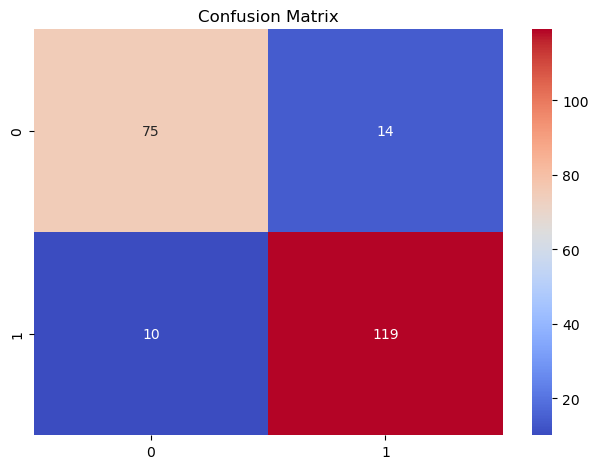

In [10]:
x_val = torch.stack([val_dataset[i][0] for i in range(len(val_dataset))]).to(device)
y_val = torch.stack([val_dataset[i][1] for i in range(len(val_dataset))]).squeeze().to(device)

with torch.no_grad():
    y_pred = model(x_val).squeeze()
    y_pred = (y_pred > 0.5).to(torch.int32)

y_val_np = y_val.cpu().numpy()
y_pred_np = y_pred.cpu().numpy()

acc = accuracy_score(y_val_np, y_pred_np)
cm = confusion_matrix(y_val_np, y_pred_np)
rep = classification_report(y_val_np, y_pred_np)

print(f'Accuracy: {acc:.4f}')
print(f'Classification Report:\n{rep}')
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [11]:
torch.save(model.state_dict(), 'heart_disease_model.pth')